# 01. Keşifçi Veri Analizi (EDA)

Bu notebook Kredi Kartı Sahtekarlık Tespiti projesinin ilk adımıdır. Veri setinin genel durumu, boyutları incelenmiş ve eksik veri ile dağılım kontrolleri yapılmıştır.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Çıktı klasörleri kontrolü
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

## 1. Veri Okuma ve Genel Bakış
Veri seti `creditcard.csv` okunmakta ve boyutlarına bakılmaktadır.

In [2]:
df = pd.read_csv('../creditcard.csv')
print("Veri Boyutu:", df.shape)
display(df.head())

Veri Boyutu: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Eksik Veri Kontrolü
Veri setindeki kayıp (missing) değerlerin sayısı grafiksel olarak incelenmiştir.

Series([], dtype: int64)


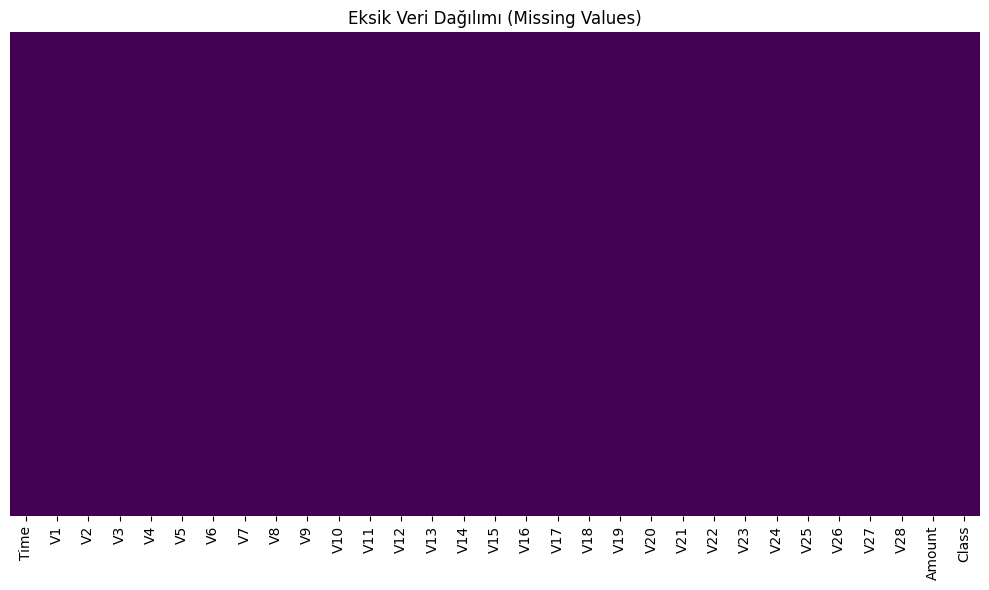

In [3]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Eksik verileri göster

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Eksik Veri Dağılımı (Missing Values)')
plt.tight_layout()
plt.savefig('../outputs/figures/missing_values.png')
plt.show()

Veri setinde hiç eksik veri olmadığı görülmektedir.

## 3. Hedef Değişken (Class) Dağılımı
Sahtekarlık tespiti projelerinde veri genellikle çok dengesizdir. Bu dengesizliği (imbalance) görmek için `Class` dağılımına bakıyoruz. (0: Normal İşlem, 1: Dolandırıcılık İşlemi)

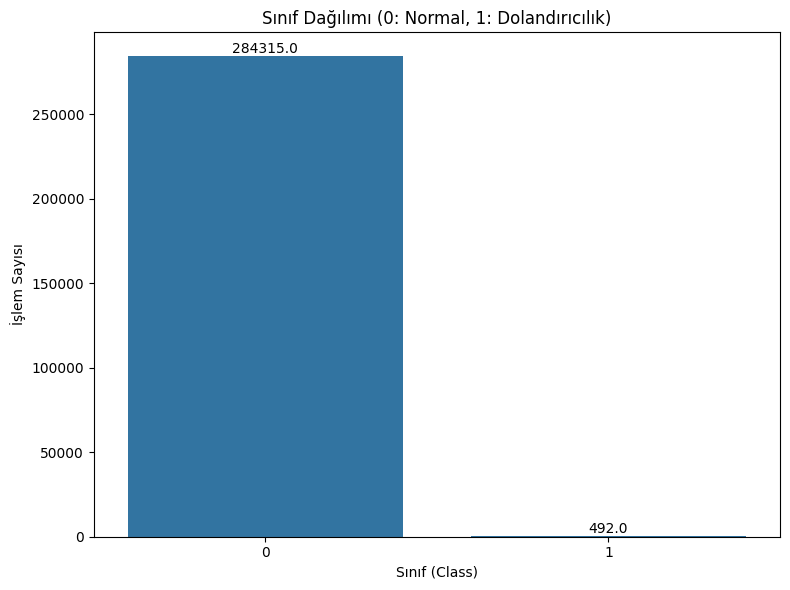

In [4]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Class')
plt.title('Sınıf Dağılımı (0: Normal, 1: Dolandırıcılık)')
plt.xlabel('Sınıf (Class)')
plt.ylabel('İşlem Sayısı')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height() + 100), ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png')
plt.show()

Grafikten görüleceği üzere Sınıf 1 (Sahtekarlık) işlemleri çok düşük bir orandadır.

## 4. Zaman (Time) ve Tutar (Amount) Dağılımları
V1-V28 sütunları PCA uygulanmış olup, Time ve Amount doğal hallerindedir.

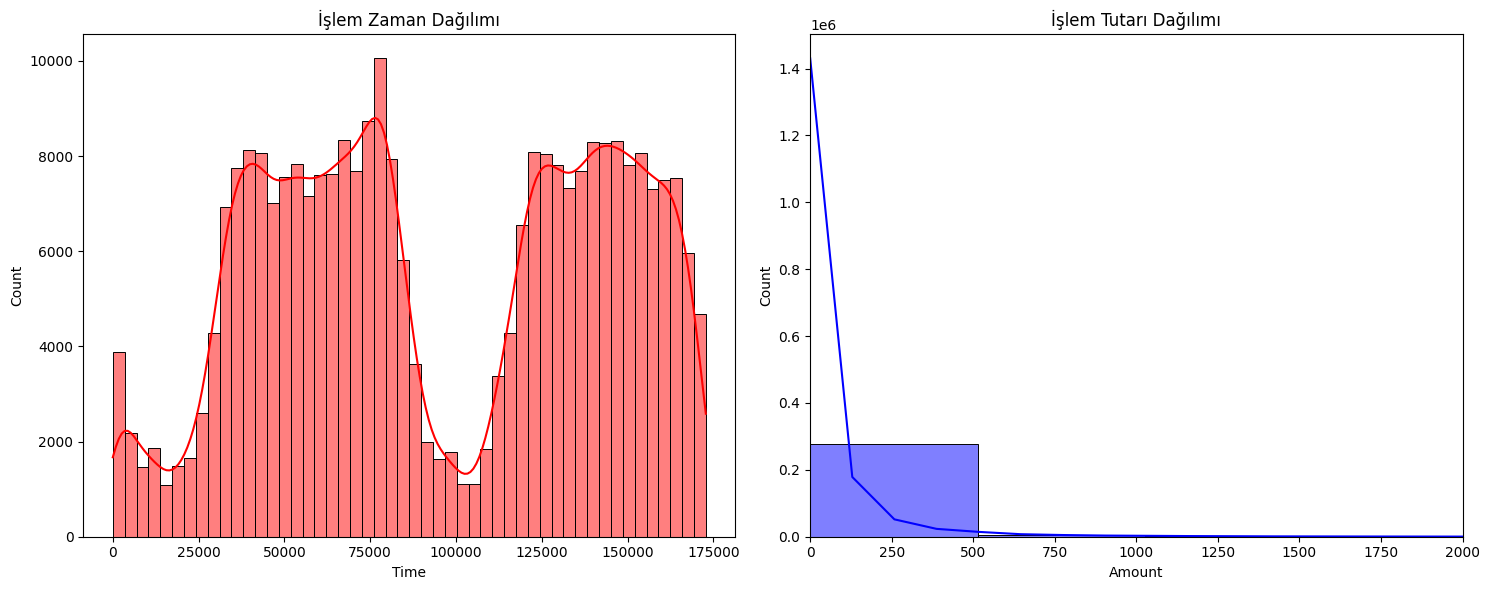

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['Time'], bins=50, kde=True, ax=ax[0], color='r')
ax[0].set_title('İşlem Zaman Dağılımı')

sns.histplot(df['Amount'], bins=50, kde=True, ax=ax[1], color='b')
ax[1].set_title('İşlem Tutarı Dağılımı')
ax[1].set_xlim([0, 2000])

plt.tight_layout()
plt.savefig('../outputs/figures/time_amount_distribution.png')
plt.show()